Hello!
I'm Kenza, and this is my first academic project in AI — I'm working with time series data! I'm super excited about this journey (even if I feel a little lazy sometimes 😅).

In this project, you'll find three main parts:

    1-Understanding and visualizing the data

    2-Processing the data

    3-Training 3 different ML models

    4-Testing our models

and yes, it will not be that boring, there are lot of plots !! 

# 1- Understanding Data : 


In the file "forecast...", we have forecasts for the year 2023, specifically for the months February to June (2–6). For each of these months, the data includes forecasts made on at least 10 different days. Each forecast extends from 6 hours up to 168 hours (7 days) into the future.

If you're wondering why only those months are included — it's because the project involves training on early data and testing on the following months. The project officially started in March and is scheduled to finish by June.

Let’s begin by uploading the first forecast from February to explore what the data looks like.

In [133]:
import pandas as pd
import random
random.seed(42)
import matplotlib.pyplot as plt
import pandas as pd
import glob
import os

In [134]:
df_01_02= pd.read_csv("Forecast data 2023/Forecast_01_02_2023.csv")
target_df = pd.read_csv('Vlinder 2023/vlinder19_2023.csv')


In [135]:
target_df.rename(columns={"datetime":"time"}, inplace=True)
target_df["time"]=pd.to_datetime(target_df["time"])

In [136]:
realT= target_df.loc[( target_df["time"]< "2023-02-08 00:00:00") &  (target_df["time" ]>"2023-02-01 00:00:00") ]

# Check the shape of the filtered dataset
realT.shape


(2015, 2)

In [137]:
df_01_02.tail(10)
#df_01_02.head(10)

,time,number,latitude,longitude,cape,sp,tcw,sshf,slhf,msl,...,skt,cin,sm,st,sd,sf,tcc,tp,mx2t6,mn2t6
1440,2023-02-08 00:00:00,41,50.75,4.25,0.000000,102953.580,9.738094,6283140.5,-12131924.0,103919.195,...,270.09402,NaN,365.76100,276.42700,0.000000,2.384186e-07,67.598630,7.662772,276.10266,272.38464
1441,2023-02-08 00:00:00,42,50.75,4.25,0.052860,102800.380,7.967748,5183689.0,-10866018.0,103765.336,...,276.26150,NaN,354.27765,277.59130,0.000000,2.384186e-07,97.274030,3.235302,278.36667,276.84634
1442,2023-02-08 00:00:00,43,50.75,4.25,1.344143,102739.320,4.407448,5494132.0,-10293728.0,103717.440,...,271.13020,NaN,351.77536,275.97867,0.010529,1.231384e-02,38.602287,2.235447,275.05298,272.34787
1443,2023-02-08 00:00:00,44,50.75,4.25,0.193314,103103.625,7.894967,7008045.0,-10031826.0,104069.090,...,276.01770,NaN,359.63782,278.25540,0.000000,2.384186e-07,30.732895,4.244598,280.05017,276.89140
1444,2023-02-08 00:00:00,45,50.75,4.25,0.000000,103234.650,5.995342,8463296.0,-12013762.0,104217.520,...,268.42690,NaN,359.50528,275.38950,0.000000,2.384186e-07,0.000000,5.455376,272.69406,269.78323
1445,2023-02-08 00:00:00,46,50.75,4.25,0.000000,102982.910,4.044870,5428415.0,-10604114.0,103957.670,...,269.20404,NaN,353.55994,275.81393,0.000000,2.384186e-07,25.294363,2.349000,274.41560,270.73068
1446,2023-02-08 00:00:00,47,50.75,4.25,18.236534,102993.390,7.551997,7786168.0,-10669408.0,103967.484,...,274.47684,NaN,355.19257,276.44843,0.000371,2.384186e-07,99.456160,3.335099,276.26523,274.87256
1447,2023-02-08 00:00:00,48,50.75,4.25,0.000000,103223.880,4.331676,7692430.0,-10128790.0,104202.630,...,269.97803,NaN,363.15363,276.21610,0.000000,2.384186e-07,0.000000,6.043367,275.26700,271.36792
1448,2023-02-08 00:00:00,49,50.75,4.25,12.574524,103089.430,9.430685,6884875.5,-8263309.0,104054.670,...,273.52280,NaN,351.33408,276.91565,0.000000,2.384186e-07,96.877290,1.240986,276.60913,274.90506
1449,2023-02-08 00:00:00,50,50.75,4.25,0.000000,102891.780,5.180458,6743563.5,-10813880.0,103863.460,...,268.01147,NaN,356.19153,275.78860,0.000000,2.384186e-07,0.001526,3.518239,273.57913,269.62305


In [138]:
#time.shape
print(df_01_02.shape[0]/50)
29/8


29.0


3.625

Each file contains 50 measurements taken at 3 different forecast hours, across 8 different days.


Below is a visualization showing the forecasts over these 8 days, organized by each measurement.

You can select a value for n from 1 to 50, which corresponds to one of the 50 measurements.
we'll use n = 3 to reduce the notebook size and keep things clean.

👉 I recommend plotting all 50 measurements at first to observe that most of them follow similar patterns — they seem to correlate quite well with each other in shape and behavior.

In [139]:
n=3

29


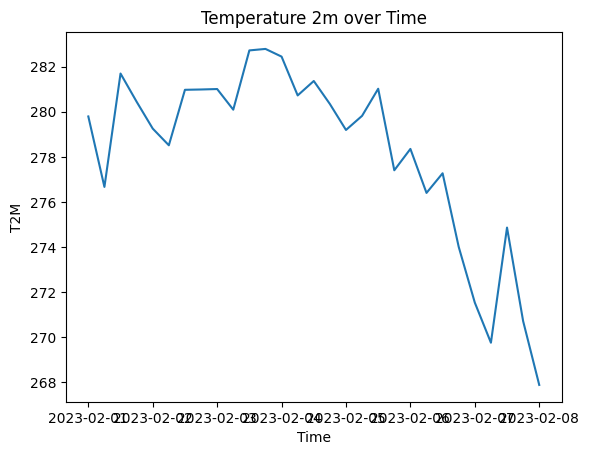

29


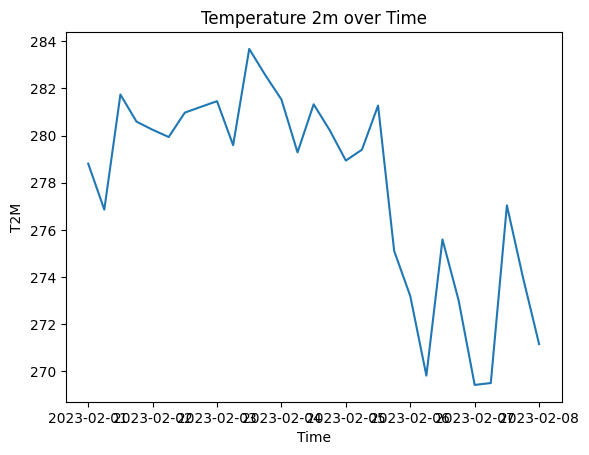

In [140]:
for i in range (1,n):
    time = pd.to_datetime(df_01_02["time"].iloc[i::50])
    t2m = pd.to_numeric(df_01_02["t2m"].iloc[i::50])
    
    print (len(time))
    plt.plot(time, t2m)
    
    plt.xlabel("Time")
    plt.ylabel("T2M")
    plt.title("Temperature 2m over Time")
    plt.show()


And this is a visualization of the actual temperature for the month of February

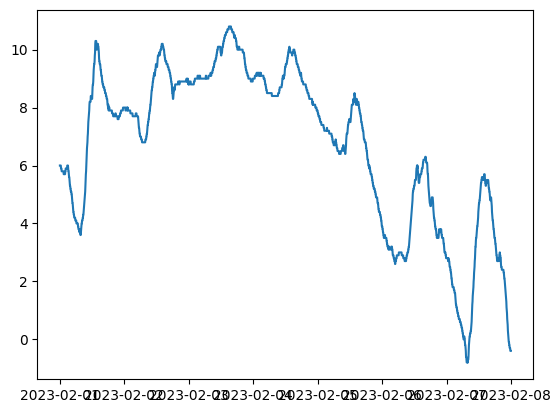

In [141]:
realT2m= pd.to_numeric(realT["temp"])
allhours=pd.to_datetime(realT["time"])
plt.plot(allhours, realT2m)

we can now upload the 28 files corresponding to different forecasting dates and merge them into one CSV file. Since the files overlap in dates, here’s how we will handle them: the closer a date is to the forecasting date, the better the forecast. Therefore, we will keep only the most recent forecast values.

We can also consider another approach. Since we are interested in weekly forecasts, for a given date X, we will retain the forecast value from the file dated X-7.

In [142]:

def merge_forecast_files(path):
    """
    Merges all forecast CSV files in the given folder, keeping only the most recent forecasts for each (time, number) pair.

    Args:
        path (str): Path to the folder containing forecast CSV files.

    Returns:
        pd.DataFrame: DataFrame with merged and deduplicated forecast data.
    """
    all_files = glob.glob(os.path.join(path, "*.csv"))
    dfs = []
    for file in all_files:
        df = pd.read_csv(file)
        df["forecast_date"] = "- ".join(os.path.basename(file).split("_")[1:]).split(".")[0]
        df["forecast_date"] = pd.to_datetime(df["forecast_date"])
        dfs.append(df)
    data = pd.concat(dfs, ignore_index=True)
    data["time"] = pd.to_datetime(data["time"])
    features_df = data.sort_values(by=["time", "forecast_date"], ascending=[True, False]).drop_duplicates(subset=["time", "number"], keep="first")
    features_df= features_df.drop(columns=["forecast_date"])
    return features_df

In [143]:
features_df = merge_forecast_files("Forecast data 2023")

C:\Users\CYTech Student\AppData\Local\Temp\ipykernel_7836\1314752156.py:16: UserWarning: Parsing dates in %d- %m- %Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["forecast_date"] = pd.to_datetime(df["forecast_date"])
C:\Users\CYTech Student\AppData\Local\Temp\ipykernel_7836\1314752156.py:16: UserWarning: Parsing dates in %d- %m- %Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["forecast_date"] = pd.to_datetime(df["forecast_date"])
C:\Users\CYTech Student\AppData\Local\Temp\ipykernel_7836\1314752156.py:16: UserWarning: Parsing dates in %d- %m- %Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["forecast_date"] = pd.to_datetime(df["forecast_date"])
C:\Users\CYTech Student\AppData\Local\Temp\ipykernel_7836\1314752156.py:16: UserWarning: Parsing dates 

Now let's import the file that contains the target value, and process it: 

In [144]:
def preprocess_target_df(target_df, start_date="2023-02-01", end_date="2023-06-30"):
    # Convert to datetime
    target_df["time"] = pd.to_datetime(target_df["time"])

    # Define date bounds
    start_date = pd.to_datetime(start_date)
    end_date = pd.to_datetime(end_date)

    # Filter date range
    target_df = target_df[(target_df["time"] >= start_date) & (target_df["time"] <= end_date)]

    # Set time as index for resampling
    target_df.set_index("time", inplace=True)

    # Resample by hour and take the first value
    target_df = target_df.resample("60T").first()

    # Reset index to get time back as a column
    target_df.reset_index(inplace=True)

    # Keep only rows with hours 00, 06, 12, 18
    target_df = target_df[
        (target_df["time"].dt.hour == 0)  | 
        (target_df["time"].dt.hour == 6)  | 
        (target_df["time"].dt.hour == 12) | 
        (target_df["time"].dt.hour == 18)
    ]
    return target_df





In [145]:
target_df = preprocess_target_df(target_df)
final_df = pd.merge(features_df, target_df, on="time", how='left')


C:\Users\CYTech Student\AppData\Local\Temp\ipykernel_7836\1769505683.py:16: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  target_df = target_df.resample("60T").first()


Here we go — we finally have a single file containing all the data across the selected months!
As a first step, let’s plot t2m (the forecasted temperature in Kelvin) alongside temp (the actual temperature from the Vlinder station).

This comparison is important because t2m serves as the baseline for our predictions. The ultimate goal of this project is to train a model that provides better forecasts than t2m.

In [146]:
def plot_forecast_vs_actual(df, start_date, end_date):
    """
    Plots forecasted temperature (t2m) and actual temperature (temp) for a given time period.

    Parameters:
    df (pd.DataFrame): DataFrame containing 'time', 't2m', and 'temp' columns.
    start_date (str or pd.Timestamp): Start of the period (inclusive).
    end_date (str or pd.Timestamp): End of the period (inclusive).
    """
    mask = (df["time"] >= pd.to_datetime(start_date)) & (df["time"] <= pd.to_datetime(end_date))
    period_df = df.loc[mask]

    x_time = period_df["time"]
    t2m = period_df["t2m"] - 273.15
    t2m_vlinder = period_df["temp"]

    plt.figure(figsize=(12, 6))
    plt.scatter(x_time, t2m, label="Forecasted Temperature (t2m, °C)", s=10)
    plt.scatter(x_time, t2m_vlinder, label="Vlinder Temperature (°C)", s=10, alpha=0.7)

    plt.xlabel("Time")
    plt.ylabel("Temperature (°C)")
    plt.title(f"Forecasted vs. Vlinder Temperature\n({start_date} to {end_date})")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


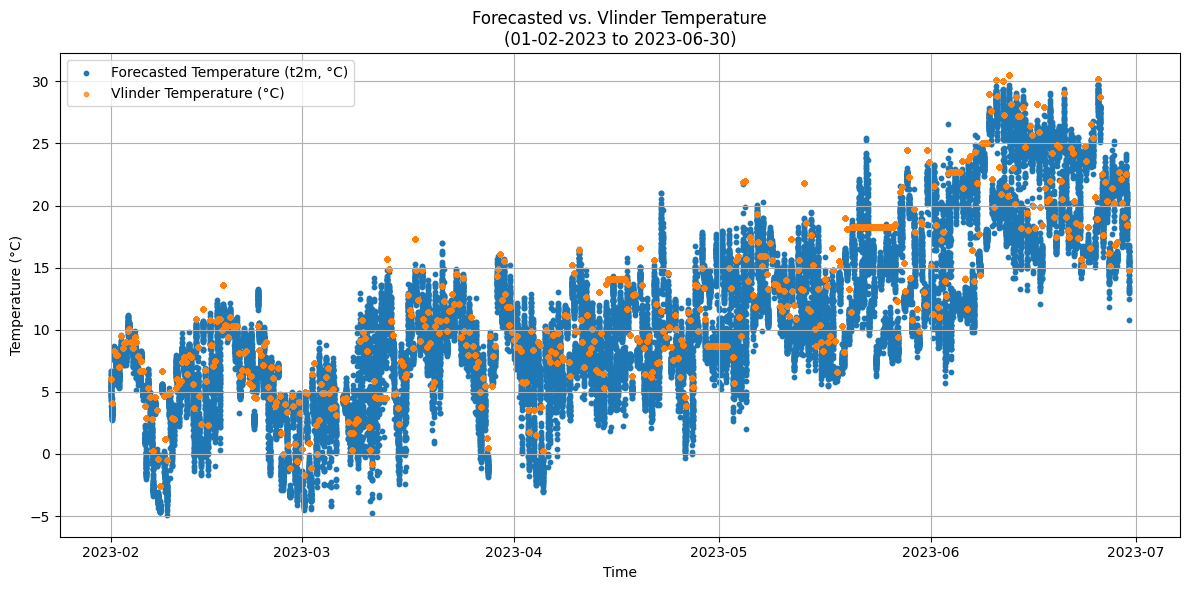

In [147]:
plot_forecast_vs_actual(final_df, "01-02-2023", end_date="2023-06-30")

Hmm... why are there so many blue points and so few orange points?  
Let's zoom in on a single month to see what's happening.

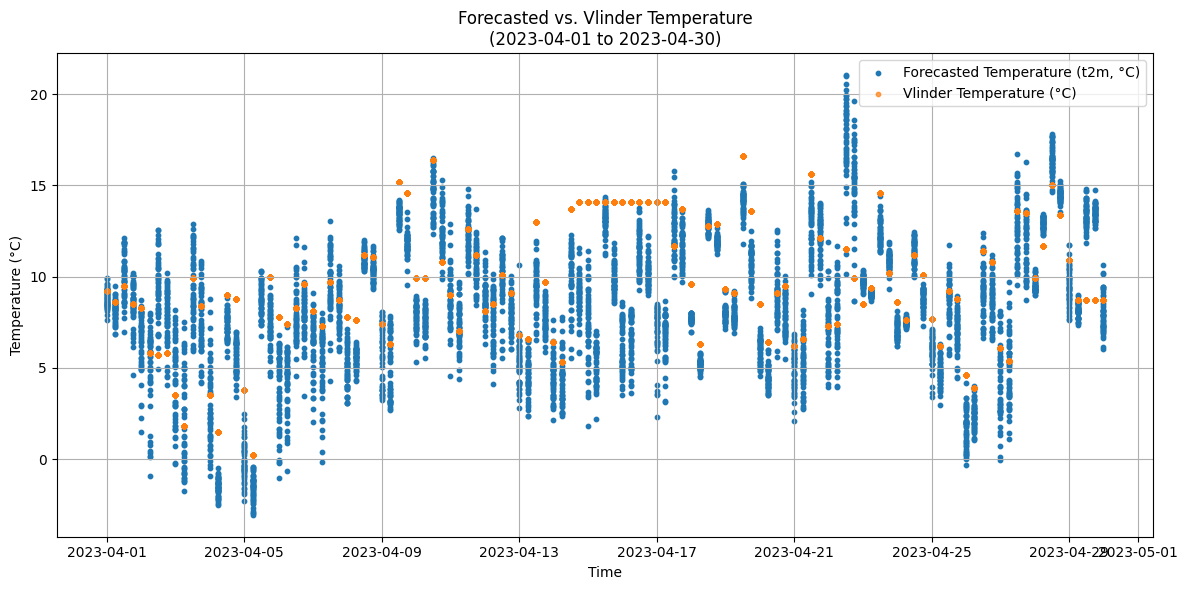

In [148]:
plot_forecast_vs_actual(final_df, "2023-04-01", end_date="2023-04-30")

Yes, of course — we have 50 predictions for every timestamp, which explains the repeated time values.
Kinda makes sense now... I'm a little "dumb" sometimes — but hey, that's how we learn!

**But hey, there’s a problem with the Vlinder temperature data: how can the real temperature remain constant for two days? Look at the period between 04-13 and 04-17.  
You can even see this issue in the previous plot.**


That's probably due to errors in the temperature measurements—perhaps the equipment was malfunctioning, or there were no staff available to record the temperatures, for example during holidays.
So they repeated the last measured value for all of those days.

For us, we just can't use those measurements, because they would mislead our models. We will deal with this in the Processing part .

_____________________________________
______________________________________________________

 # 2- Processing data :

Let's first address the errors in the real temperature measurements that we just observed.

### 2-1 Error Metrics for Vlinder Temperature Measurements

In [149]:
def find_constant_temp(df):

    """
    Find constant temperature over two timestamps  in the DataFrame.
    
    Parameters:
    df (pd.DataFrame): DataFrame containing temperature data.
    
    Returns:
    list: List of time values where the temperature is constant.
    """

    index = 0
    temp_to_delete = []
    while index < len(final_df) - 50:
        if final_df.iloc[index]["temp"] == final_df.iloc[index + 50]["temp"]:
            temp_to_delete.append(final_df.iloc[index]["time"])
            index += 50
        else:       
            index += 50  
    
    return temp_to_delete



In [150]:
temp_to_delete = find_constant_temp(final_df)

print(temp_to_delete)

final_df = final_df.drop(final_df[final_df["time"].isin(temp_to_delete)].index)

[Timestamp('2023-02-01 18:00:00'), Timestamp('2023-02-16 18:00:00'), Timestamp('2023-02-18 18:00:00'), Timestamp('2023-02-19 00:00:00'), Timestamp('2023-02-19 06:00:00'), Timestamp('2023-03-04 00:00:00'), Timestamp('2023-03-12 00:00:00'), Timestamp('2023-03-12 06:00:00'), Timestamp('2023-03-12 12:00:00'), Timestamp('2023-03-12 18:00:00'), Timestamp('2023-03-13 00:00:00'), Timestamp('2023-03-23 12:00:00'), Timestamp('2023-04-10 00:00:00'), Timestamp('2023-04-14 18:00:00'), Timestamp('2023-04-15 00:00:00'), Timestamp('2023-04-15 06:00:00'), Timestamp('2023-04-15 12:00:00'), Timestamp('2023-04-15 18:00:00'), Timestamp('2023-04-16 00:00:00'), Timestamp('2023-04-16 06:00:00'), Timestamp('2023-04-16 12:00:00'), Timestamp('2023-04-16 18:00:00'), Timestamp('2023-04-17 00:00:00'), Timestamp('2023-04-29 06:00:00'), Timestamp('2023-04-29 12:00:00'), Timestamp('2023-04-29 18:00:00'), Timestamp('2023-04-30 00:00:00'), Timestamp('2023-04-30 06:00:00'), Timestamp('2023-04-30 12:00:00'), Timestamp('20

Now, let's verify that we have fixed the problem.

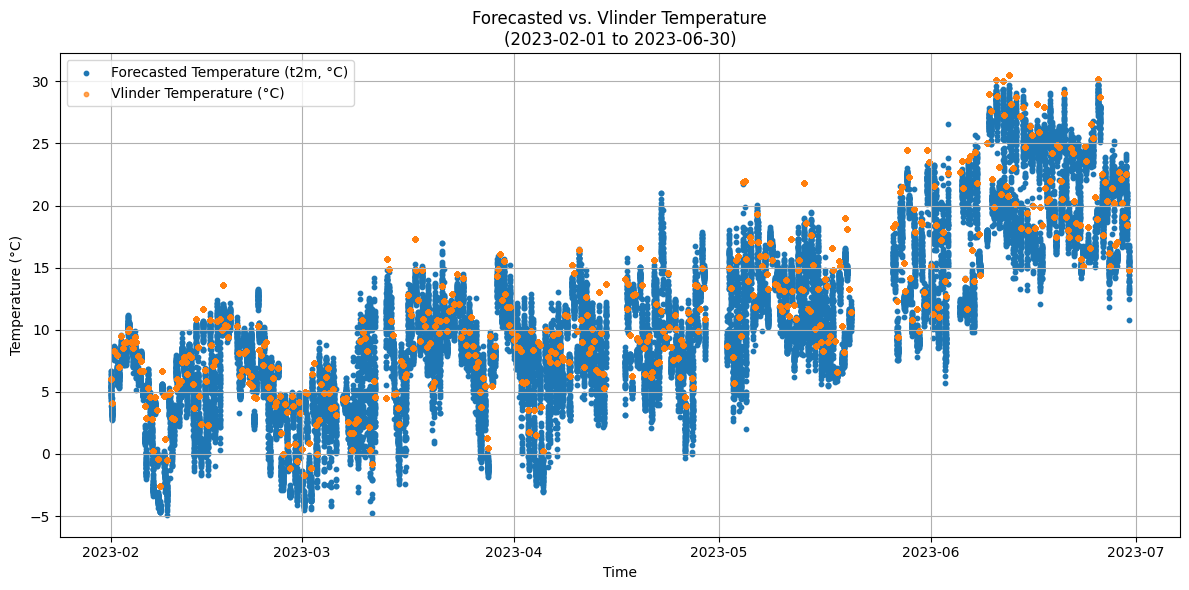

In [151]:
plot_forecast_vs_actual(final_df, "2023-02-01", end_date="2023-06-30")

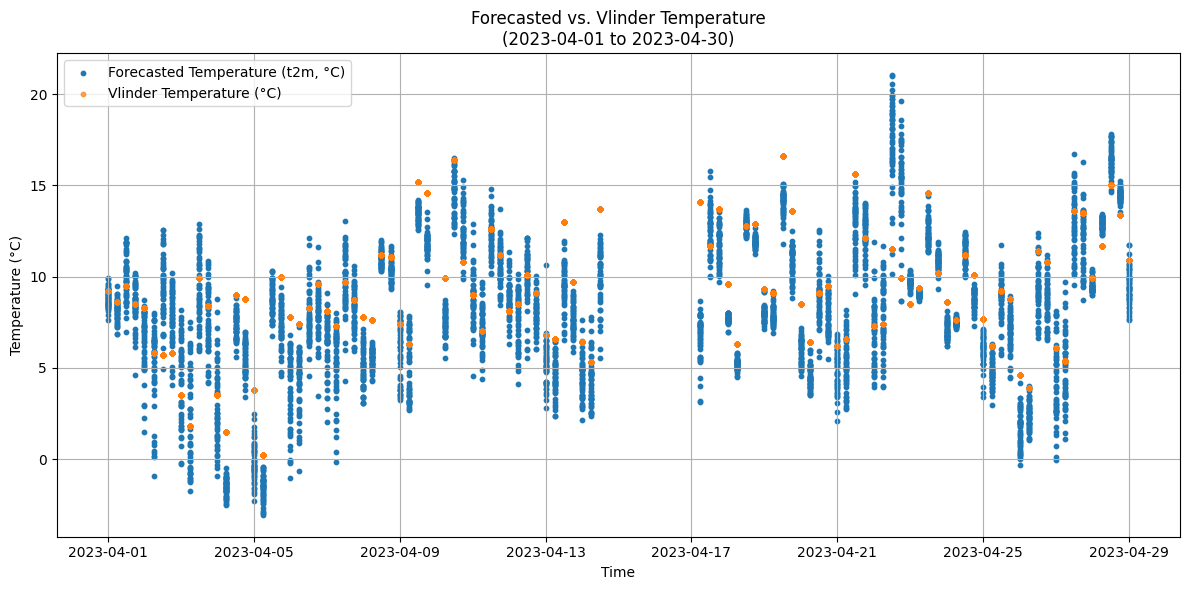

In [152]:
plot_forecast_vs_actual(final_df, "2023-04-01", end_date="2023-04-30")

Good, we don't have this problem of constant temperature anymore.

In [153]:
# S'assurer que "time" est au format datetime
final_df["time"] = pd.to_datetime(final_df["time"])

# Trouver les doublons en considérant date et heure
duplicates = final_df[final_df["time"].duplicated(keep=False)]

# Afficher les doublons
print(duplicates["time"].head(2))


0   2023-02-01
1   2023-02-01
Name: time, dtype: datetime64[ns]


### 2-2 Removing Unnecessary Columns and Handling Missing Values

with this code, we will identify the columns that have more than 60% missing values or values equal to 0, as well as the columns that have any missing values.



In [154]:
def missing_values(df):

    L = []
    LMV = []  # more than 60% null or equal to zero
    
    MV = []  # columns that have missing values
    
    i=0
    for col in df.columns:
        L.append((i, df[col].isnull().sum() / df.shape[0], (df[col] == 0).sum() / df.shape[0]))
        i += 1

    LMV = [df.columns[L[i][0]] for i in range(len(L)) if (L[i][1] >= 0.6 or L[i][2] >= 0.6)]
    MV = [df.columns[L[i][0]] for i in range(len(L)) if (L[i][1] != 0)]
   

    
    return LMV, MV


    
    

In [155]:
LMV, MV = missing_values(final_df)
print("Columns with a lot of missing values (more than 60%) , or the constant 0 in 60 % of rows :", LMV)
print("Columns that have missing values:", MV)

Columns with a lot of missing values (more than 60%) , or the constant 0 in 60 % of rows : ['cin', 'sd', 'sf']
Columns that have missing values: ['cin', 'mx2t6', 'mn2t6', 'temp']


In [156]:

# Show timestamps where 'temp' is missing in final_df
print("Timestamps with missing temp in final_df:")
print(final_df["time"][final_df["temp"].isnull()].drop_duplicates())

# Show timestamps where 'temp' is missing in target_df
print("Timestamps with missing temp in target_df:")
print(target_df["time"][target_df["temp"].isnull()])

# Check if target_df contains data for July (month 7)
print("Does target_df have data for July?")
print(target_df["time"][target_df["time"] == "2023-07-01 18:00:00"])

Timestamps with missing temp in final_df:
12550   2023-04-05 12:00:00
29700   2023-06-30 06:00:00
29750   2023-06-30 12:00:00
29800   2023-06-30 18:00:00
29850   2023-07-01 00:00:00
29900   2023-07-01 06:00:00
29950   2023-07-01 12:00:00
30000   2023-07-01 18:00:00
30050   2023-07-02 00:00:00
30100   2023-07-02 06:00:00
30150   2023-07-02 12:00:00
30200   2023-07-02 18:00:00
30250   2023-07-03 00:00:00
30300   2023-07-03 06:00:00
30350   2023-07-03 12:00:00
30400   2023-07-03 18:00:00
30450   2023-07-04 00:00:00
30500   2023-07-04 06:00:00
30550   2023-07-04 12:00:00
30600   2023-07-04 18:00:00
30650   2023-07-05 00:00:00
Name: time, dtype: datetime64[ns]
Timestamps with missing temp in target_df:
1524   2023-04-05 12:00:00
Name: time, dtype: datetime64[ns]
Does target_df have data for July?
Series([], Name: time, dtype: datetime64[ns])


From the code above, we see that some values in "temp" are missing in `final_df`. For example, the actual temperature at `'2023-04-05 12:00:00'` is missing in `final_df` because it is also missing in `target_df`.

To address this, we will simply delete these rows, since we have a lot of data and do not want to introduce bias by imputing values.

For the remaining missing values, we have two options: either remove the rows with missing data, or extend `target_df` up to `'2023-07-05 00:00:00'` to include more data.

For now, we will proceed by deleting the rows with missing values. We can revisit and improve this approach later, as having a larger training dataset could help our model learn better.


In [157]:

final_df=final_df.dropna(subset=["temp"])

For other columns that have missing values, we will delete them along with columns that have a lot of missing values. The reason is that if we try to drop rows with missing values for every column, we end up deleting up to 80% of the timestamps in some test sets. Therefore, it's more efficient to remove entire columns with excessive missing data.

In [158]:
LMV, MV = missing_values(final_df)

In [159]:
colomns_to_delete = LMV + MV
print("Columns to delete:", colomns_to_delete)
final_df = final_df.drop(columns=colomns_to_delete)

Columns to delete: ['cin', 'sd', 'sf', 'cin', 'mx2t6', 'mn2t6']


###  2-3 Normalizing data 


Before training machine learning models, it is important to normalize the data because the features have different units and scales (for example, temperature in Kelvin, pressure in hPa, etc.). Normalization ensures that each feature contributes equally to the model and helps algorithms converge faster.

In this project, we use `StandardScaler` from scikit-learn to standardize the features (mean = 0, standard deviation = 1). This is especially important for linear models and neural networks.

Normalization is applied to all numerical columns except the target variable (`temp`), which is normalized separately. This allows us to later inverse-transform the predictions to the original temperature scale for interpretation.  
Also, the columns "number", 'hour', 'week', 'month', they are actually categorical, so we do not normalize it, as it would not make sense.

#### But to avoid **data snooping**, we do **not** normalize the data before splitting it into "training" and "validation" sets. If we normalize before splitting, the mean and standard deviation are calculated using the entire dataset—including the validation rows—which can lead to overly optimistic performance estimates. Instead, we split the data first, then fit the scaler only on the training set, and finally apply the same transformation to the validation set. This ensures a fair evaluation of model performance.

so we will call this function later .


In [160]:
from sklearn.preprocessing import StandardScaler

def normalize_data(df, target_column=None):
    # Create the scaler for X
    scaler_X = StandardScaler()

    # Identify numerical columns, except 'number', 'hour', 'week', 'month'
    exclude_cols = ['number', 'hour', 'week', 'month']
    numeric_columns = [col for col in df.select_dtypes(include=['float64', 'int64']).columns if col not in exclude_cols]

    # If target_column is specified, process X and y
    if target_column is not None:
        scaler_y = StandardScaler()

        # Separate X and y
        X = df.drop(columns=[target_column])
        y = df[[target_column]]

        # Numerical columns for X, except 'number'
        numeric_columns_X = [col for col in X.select_dtypes(include=['float64', 'int64']).columns if col != 'number']

        # Normalize
        X_scaled = scaler_X.fit_transform(X[numeric_columns_X])
        y_scaled = scaler_y.fit_transform(y)

        # Rebuild DataFrame X
        X_scaled_df = X.copy()
        X_scaled_df[numeric_columns_X] = X_scaled

        return X_scaled_df, y_scaled, scaler_X, scaler_y

    else:
        # Normalize the numerical columns in the DataFrame
        df_scaled = df.copy()
        df_scaled[numeric_columns] = scaler_X.fit_transform(df[numeric_columns])

        return df_scaled, scaler_X



### 2-4 Feature Engineering

Linear regression models require all input features to be numerical. Therefore, we need to transform any non-numerical columns into numerical features before training the model.

In [161]:
def convert_time_to_int (df):
    # Ensure 'time' is in datetime forma 
    df['time'] = pd.to_datetime(df['time'])
    #Extract features from the 'time' column

    df['day'] =df['time'].dt.day   
    
    df['hour'] =df['time'].dt.hour  # Hour of the day
    df['month'] =df['time'].dt.month  # Month of the year
    df['week'] = df['time'].dt.isocalendar().week  #  we will use it for splitting the data.
    
    return df
    


In [162]:

final_df =convert_time_to_int(final_df)


## 3 - Splitting Data

We will split the data as follows: for each month, we will use the first three weeks as training data and the last week as validation data. This approach ensures that the training set includes data from all months, while the validation set tests the model on unseen time periods.

In [163]:

def get_train_val_indices(final_df):
    train_indices = []
    val_indices = []
    for month in final_df['month'].unique():
        month_df = final_df[final_df['month'] == month].copy()
        # Get unique weeks in this month, sorted
        weeks = sorted(month_df['week'].unique())
        # Assign first 3 weeks to train, last week to validation
        train_weeks = weeks[:3]
        val_weeks = weeks[3:]
        train_indices.extend(month_df[month_df['week'].isin(train_weeks)].index.tolist())
        val_indices.extend(month_df[month_df['week'].isin(val_weeks)].index.tolist())
    return train_indices, val_indices




In [164]:
train_indices, val_indices = get_train_val_indices(final_df)


train_df_X, train_df_y, scaler_X, scaler_y = normalize_data(final_df.loc[train_indices], target_column='temp')
val_df_X = final_df.loc[val_indices].drop(columns=['temp']).reset_index(drop=True)
val_df_y = final_df.loc[val_indices][['temp']].reset_index(drop=True)

# Apply the scaler fitted on train to validation data
numeric_columns_X = [col for col in val_df_X.select_dtypes(include=['float64', 'int64']).columns if col != 'number']
val_df_X[numeric_columns_X] = scaler_X.transform(val_df_X[numeric_columns_X])
val_df_y[['temp']] = scaler_y.transform(val_df_y[['temp']])

and here a visulazion of how we split it if it's unclear.

C:\Users\CYTech Student\AppData\Local\Temp\ipykernel_7836\1316536416.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab20', len(months))


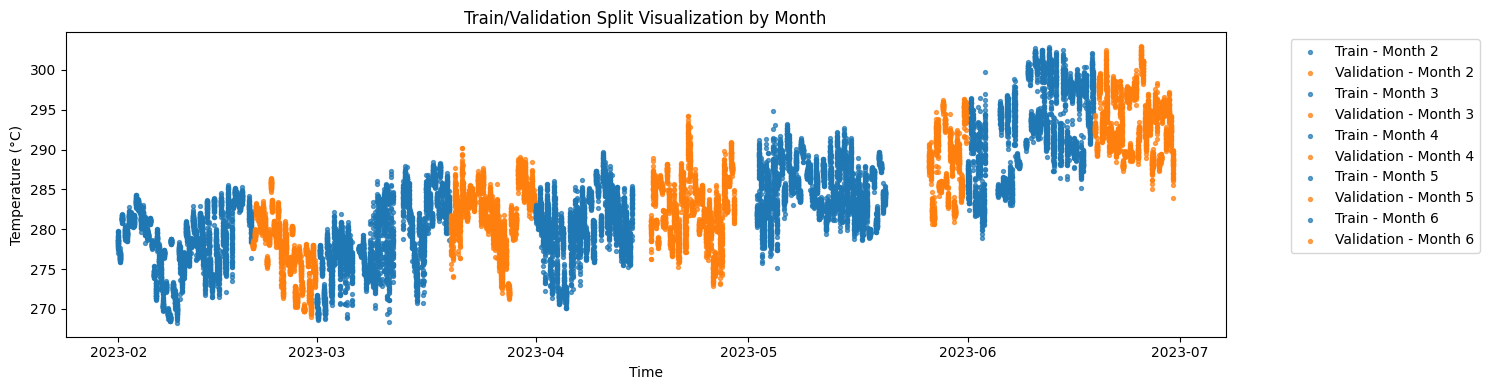

In [165]:
# Prepare a DataFrame with split labels for visualization
split_df = final_df.copy()
split_df['split'] = 'none'

# Mark splits based on indices in X_scaled_df
# Mark splits based on indices in X_scaled_df
split_df.loc[train_indices, 'split'] = 'train'
split_df.loc[val_indices, 'split'] = 'validation'

# Plot
plt.figure(figsize=(15, 4))
months = split_df['month'].unique()
colors = plt.cm.get_cmap('tab20', len(months))

for i, month in enumerate(sorted(months)):
    for split, marker in zip(['train', 'validation'], ['o', 'x']):
        mask = (split_df['split'] == split) & (split_df['month'] == month)
        plt.scatter(
            split_df.loc[mask, 'time'],
            split_df.loc[mask, 't2m'],
            label=f"{split.capitalize()} - Month {month}" if split == 'train' else f"{split.capitalize()} - Month {month}",
            s=8,
            alpha=0.7,
            color='tab:blue' if split == 'train' else 'tab:orange'
        )

plt.xlabel('Time')
plt.ylabel('Temperature (°C)')
plt.title('Train/Validation Split Visualization by Month')
# Only show legend for the first month to avoid clutter
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



In [166]:
#let's delete the column time, it's not needed anymore
train_df_X = train_df_X.drop(columns=["time"])
val_df_X = val_df_X.drop(columns=["time"])

______________________
_______________________________________

# 3-Training models:

After training the model, we want to visualize the three key temperature series for the validation set:

1. Real temperature (from the Vlinder station)
2. Forecasted temperature (the original t2m forecast)
3. Model-corrected temperature (predicted by our model)
This comparison helps us assess how much our model improves upon the baseline forecast and how closely it matches the actual observed temperatures.


So we will code this function here, and call it for every modele, and all the model in testing phase.



In [167]:
def simple_data(df, target, real_temp, target2=None, target3=None):
    # Select only the needed columns
    df = df[["month", "day", "hour", "t2m", "number"]].copy()
    
    # Add the year column with default value 2023
    df['year'] = 2023

    # Create column time from columns: "year", "month", "day", "hour"
    df['time'] = pd.to_datetime(dict(year=df['year'], month=df['month'], day=df['day'], hour=df['hour']))

    # Add the target columns
    df['t2m_corrected'] = target
    df['t2m_real'] = real_temp

    # Optionally add target2 and target3
    if target2 is not None:
        df['target2'] = target2
    if target3 is not None:
        df['target3'] = target3

    # Columns to aggregate
    agg_cols = ['t2m', 't2m_corrected', 't2m_real']
    rename_dict = {
        't2m': 't2m_mean',
        't2m_corrected': 't2m_corrected_mean',
        't2m_real': 't2m_real_first'
    }
    if target2 is not None:
        agg_cols.append('target2')
        rename_dict['target2'] = 'target2_mean'
    if target3 is not None:
        agg_cols.append('target3')
        rename_dict['target3'] = 'target3_mean'

    # Group by time and aggregate
    result = df.groupby('time', as_index=False)[agg_cols].mean()

    # Rename the columns
    result = result.rename(columns=rename_dict)
    result['t2m_mean'] = result['t2m_mean'] - 273.15

    return result

In [168]:
# Only inverse transform the columns that were originally scaled
numeric_columns = [col for col in val_df_X.columns if col in scaler_X.feature_names_in_]
val_df_X_copy = val_df_X.copy()
val_df_X_copy[numeric_columns] = scaler_X.inverse_transform(val_df_X[numeric_columns])



In [169]:


def plot_temperatures(
    df, time_col, col1, col2, col3, 
    label1='Predicted', label2='Forecasted', 
    col4=None, label4=None, 
    col5=None, label5=None,
    ylim=None,
    yticks_step=None  # Ajoute un argument pour le pas des graduations
):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(14, 6))
    plt.plot(df[time_col], df[col1], label=label1, color='orange')
    plt.plot(df[time_col], df[col2], label=label2, color='blue')
    plt.plot(df[time_col], df[col3], label='Real', color='green')
    if col4 is not None and label4 is not None:
        plt.plot(df[time_col], df[col4], label=label4, color='red')
    if col5 is not None and label5 is not None:
        plt.plot(df[time_col], df[col5], label=label5, color='purple')
    plt.xlabel('Time')
    plt.ylabel('Temperature (°C)')
    plt.title(f'{label1} vs {label2} Over Time')
    plt.legend()
    plt.grid(True)
    if ylim is not None:
        plt.ylim(ylim)
    if yticks_step is not None:
        ymin, ymax = plt.ylim()
        plt.yticks(np.arange(np.floor(ymin), np.ceil(ymax)+1, yticks_step))
    plt.tight_layout()
    plt.show()


## 3-1 Linear Regression

In [170]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np
from sklearn.feature_selection import RFECV

We will train first a linear regression model,  with selecting  the best features for prediction. We will use cross-validation and Recursive Feature Elimination with Cross-Validation (RFECV) for this task.



Recursive Feature Elimination (RFE) is a greedy optimization algorithm which aims to find the best performing feature subset. It repeatedly creates models and keeps aside the best or the worst performing feature at each iteration. It constructs the next model with the left features until all the features are exhausted. It then ranks the features based on the order of their elimination. It uses accuracy metric to rank the feature according to their importance. The RFE method takes the model to be used and the number of required features as input. It then gives the ranking to all variables, 1 being the most important. It also gives it support, True being relevant feature and False being irrelevant feature. As the name suggests, this method eliminates worst performing features on a particular model one after the other until the best subset of features are known.

In [171]:
from sklearn.metrics import mean_absolute_error


y_val_real = scaler_y.inverse_transform(val_df_y)
y_train_real = scaler_y.inverse_transform(train_df_y)


# Use Recursive Feature Elimination with Cross-Validation for feature selection
selector = RFECV(
    estimator=LinearRegression(),
    step=1,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

# Fit selector on training data (use DataFrame for column names)
y_train = train_df_y.ravel()
selector.fit(train_df_X.values, y_train)

# Get selected features
selected_features = train_df_X.columns[selector.support_]
print("Selected features:", list(selected_features))

# Transform train and validation sets to keep only selected features
X_train_selected = selector.transform(train_df_X.values)
X_val_selected = selector.transform(val_df_X.values)

# Retrain model with selected features
model_selected = LinearRegression()
model_selected.fit(X_train_selected, y_train)

# Predict and evaluate
y_pred_val_selected_scaled = model_selected.predict(X_val_selected)
y_pred_val_selected = scaler_y.inverse_transform(y_pred_val_selected_scaled.reshape(-1, 1))
y_pred_train_selected_scaled = model_selected.predict(X_train_selected)
y_pred_train_selected = scaler_y.inverse_transform(y_pred_train_selected_scaled.reshape(-1, 1))

# Calculate MAE
mae_train_selected = mean_absolute_error(y_train_real, y_pred_train_selected)
mae_selected = mean_absolute_error(y_val_real, y_pred_val_selected)

# Calculate sMAPE
def smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

smape_selected = smape(y_val_real, y_pred_val_selected)
smape_train_selected = smape(y_train_real, y_pred_train_selected)

# Show results in a table
results_df = pd.DataFrame({
    "Metric": ["MAE", "sMAPE"],
    "Value_validation": [mae_selected, smape_selected],
    "Value_train": [mae_train_selected, smape_train_selected]
})
print(results_df)


Selected features: ['sp', 'msl', 't2m', 'skt', 'st']
  Metric  Value_validation  Value_train
0    MAE          1.539677     1.517090
1  sMAPE         16.067386    21.287755


### Interpretation :


The linear regression model achieves a mean absolute error (MAE) of about 1.54°C on the validation set and 1.52°C on the training set. This means that, on average, the model's predictions are within 1.5°C of the actual temperature. The symmetric mean absolute percentage error (sMAPE) is 16% for validation and 21.3% for training, indicating that the model's relative error is low and consistent across both sets. These results suggest good generalization and minimal overfitting.

---

#### Selected Features and Their Interpretation

The features selected by the model are:

- **sp**: Surface pressure
- **msl**: Mean sea level pressure
- **t2m**: Baseline forecasted temperature at 2 meters (the value we aim to correct)
- **skt**: Skin temperature
- **st**: Soil temperature

These selections make sense physically: the actual temperature is influenced by atmospheric pressure (both at the surface and sea level), the baseline forecast, and the temperatures of the ground and soil layers. 



#### Plotting the measurements

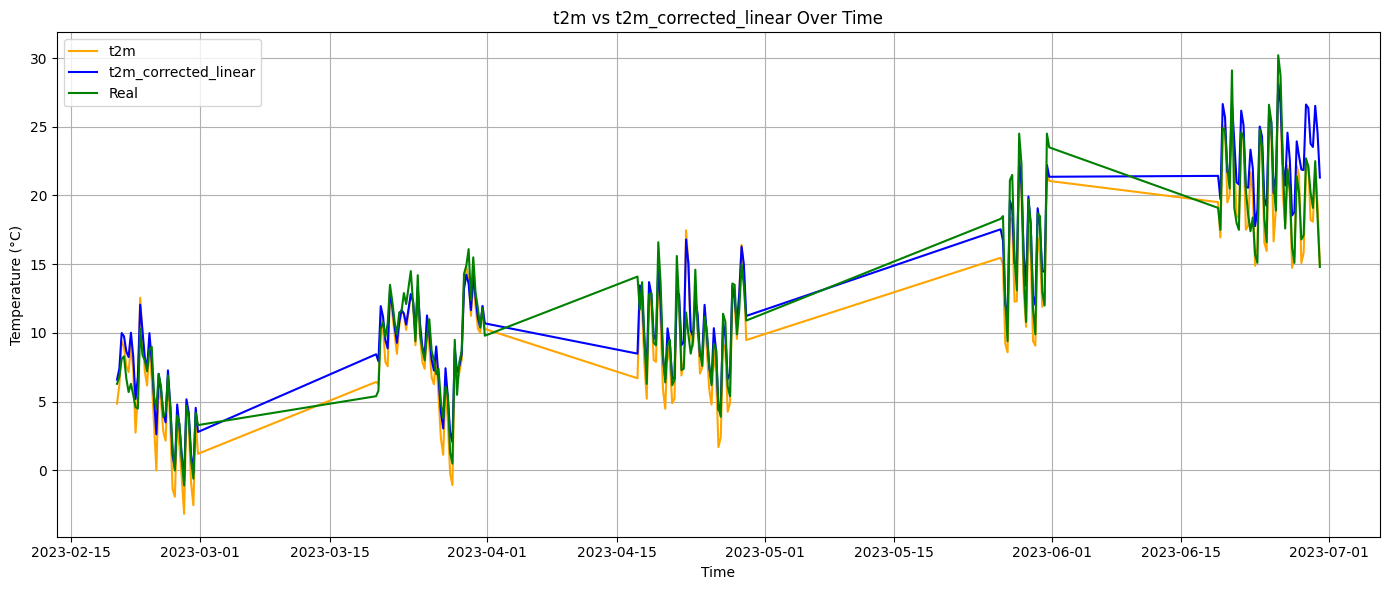

In [172]:
df = simple_data(val_df_X_copy, y_pred_val_selected, y_val_real)
plot_temperatures(df, 'time', 't2m_mean', 't2m_corrected_mean', 't2m_real_first', label1='t2m', label2='t2m_corrected_linear')

it looks okay, there is an improvement as the average corrected t2m by our model is closer to the real t2m than the average of the forecasted (naive) t2m.

But it looks like our model is slightly overestimating the temperature in march and july.

The reason why the model is overestimating maybe is because For each period in the validation data, the closest corresponding period in the training data is colder, which leads the model to predict higher temperatures than actually observed.

## 3-2 XGBoost

XGBoost, which stands for Extreme Gradient Boosting, is a highly efficient and scalable machine learning library designed for supervised learning tasks such as regression and classification. It is based on the gradient boosting framework, where an ensemble of decision trees is built sequentially, with each new tree aiming to correct the errors of the previous ones. XGBoost is known for its speed and performance, thanks to optimizations like parallel processing, tree pruning, and efficient handling of missing values. It also includes regularization techniques (L1 and L2) to help prevent overfitting, making it robust for real-world data. XGBoost is widely used in data science competitions and industry projects because it consistently delivers high accuracy, especially on structured/tabular datasets. Its flexibility, ability to handle large datasets, and support for custom loss functions make it a popular choice among practitioners.

Let's first upload the packages we need if it's not already done.

In [173]:
%pip install xgboost
%pip install graphviz

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


here we train the model, we already handle tuning the hyper parameters of the model by using a gridSearch with 3 cross validation . 

In [174]:
# Prepare data (use all features)
X_train = train_df_X.values
y_train = train_df_y.ravel()
X_val = val_df_X.values
y_val = val_df_y.values.ravel()

In [175]:

from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor, plot_tree



# Define parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

xgb = XGBRegressor( objective='reg:squarederror', random_state=42, n_jobs=-1)
grid_search = GridSearchCV(xgb, param_grid, cv=3, scoring='neg_mean_absolute_error', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best model
best_xgb = grid_search.best_estimator_

# Predict and inverse transform
y_pred_train_scaled = best_xgb.predict(X_train)
y_pred_val_scaled = best_xgb.predict(X_val)
y_pred_train = scaler_y.inverse_transform(y_pred_train_scaled.reshape(-1, 1))
y_pred_val = scaler_y.inverse_transform(y_pred_val_scaled.reshape(-1, 1))
y_train_real = scaler_y.inverse_transform(y_train.reshape(-1, 1))
y_val_real = scaler_y.inverse_transform(y_val.reshape(-1, 1))

# Metrics
def smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

mae_train = mean_absolute_error(y_train_real, y_pred_train)
mae_val = mean_absolute_error(y_val_real, y_pred_val)
smape_train = smape(y_train_real, y_pred_train)
smape_val = smape(y_val_real, y_pred_val)


# Show results in a table
results_df = pd.DataFrame({
    "Metric": ["MAE", "sMAPE"],
    "Value_validation": [mae_val, smape_val],
    "Value_train": [mae_train, smape_train]
})
print(results_df)





Fitting 3 folds for each of 36 candidates, totalling 108 fits
  Metric  Value_validation  Value_train
0    MAE          1.588734     1.170911
1  sMAPE         19.826808    18.295608


### Interpretation:

The XGBoost model achieves a mean absolute error (MAE) of about **1.59°C** on the validation set and **1.17°C** on the training set. This means that, on average, the model’s predictions are within 1.6°C of the actual temperature for unseen data, and even closer for the training data. The symmetric mean absolute percentage error (sMAPE) is **19.8%** for validation and **18.3%** for training, indicating that the model’s relative error is reasonably low and consistent across both sets.

These results show that XGBoost is able to capture complex relationships in the data and generalizes well, with only a small gap between training and validation errors—suggesting minimal overfitting. Compared to the linear regression model, XGBoost provides slightly better accuracy, especially on the training set, thanks to its ability to model non-linear interactions between features.

The feature importance plot (see your notebook) highlights which variables XGBoost relies on most for its predictions. Typically, features like **t2m** (forecasted temperature), **sp** (surface pressure), and other meteorological variables are among the most important, which aligns with physical expectations for weather forecasting.

**Conclusion:**  
XGBoost delivers robust and accurate temperature forecasts, outperforming linear regression by leveraging more complex patterns in the data, while still maintaining good generalization to unseen data.

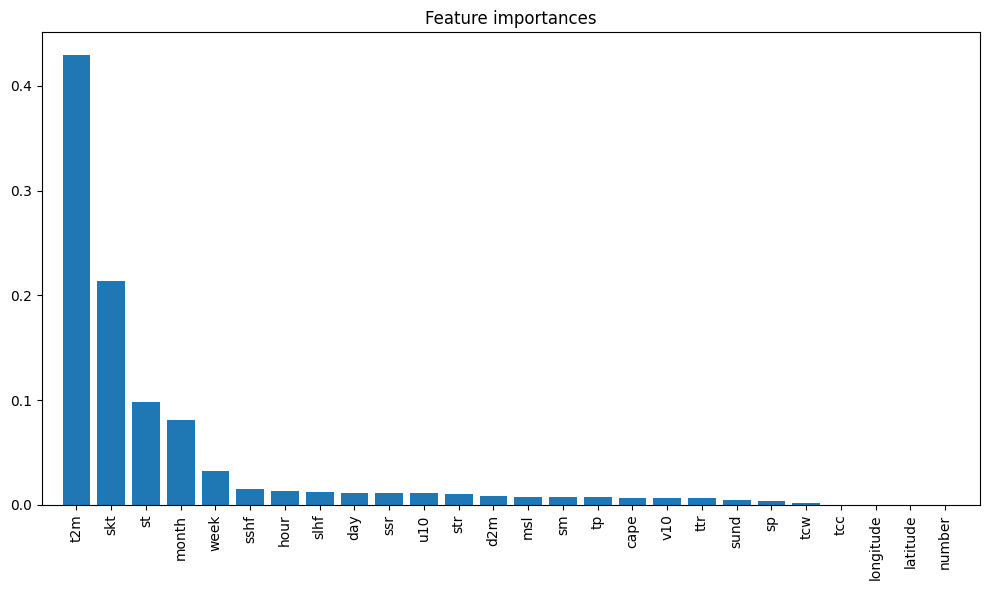

In [176]:
# Plot feature importances
importances = best_xgb.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10, 6))
plt.title("Feature importances")
plt.bar(range(X_train.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), np.array(train_df_X.columns)[indices], rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.tight_layout()
plt.show()

The top 3 important features for the model are the same as for linear regression. However, for XGBoost, the "month" feature is more important, which actually makes sense—temperature varies with the seasons, so the month provides valuable information for forecasting.

plotting two example trees

c:\Users\CYTech Student\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


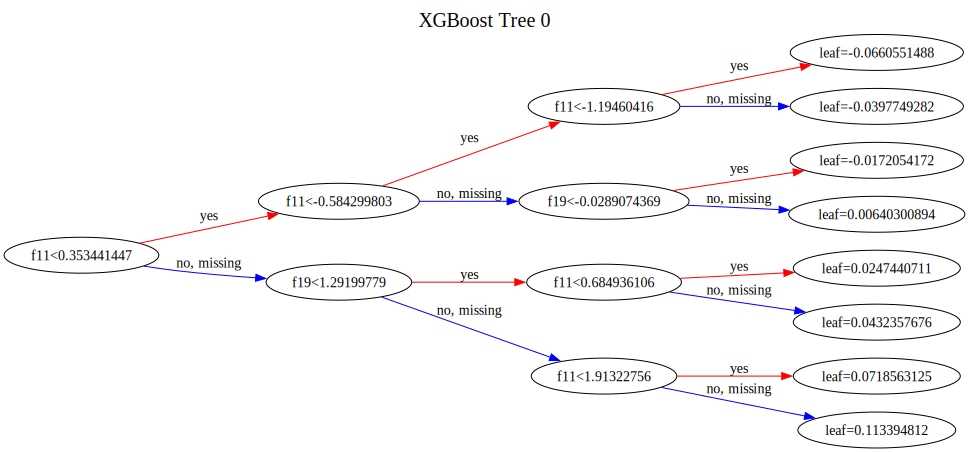

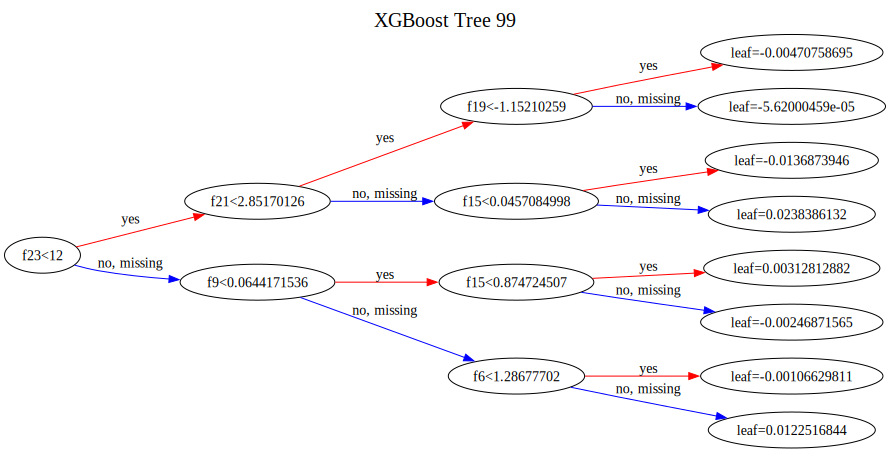

In [177]:
from xgboost import to_graphviz
from graphviz import Source
from IPython.display import display

def plot_xgb_tree(model, num_tree, filename='xgb_tree'):
    """
    Plots and saves a specific tree from a fitted XGBoost model.

    Parameters:
    model: fitted XGBRegressor
    num_tree: int, index of the tree to plot (0-based)
    filename: str, base filename for saving the SVG
    """
   

    dot = to_graphviz(model, num_trees=num_tree, rankdir='LR')
    # Insert the label after the first '{'
    dot_source = dot.source
    insert_str = f'\nlabel="XGBoost Tree {num_tree}"; labelloc=top; fontsize=20;'
    first_brace = dot_source.find('{')
    if first_brace != -1:
        dot_source = dot_source[:first_brace+1] + insert_str + dot_source[first_brace+1:]
    
    dot_with_title = Source(dot_source)
    dot_with_title.render(filename, format='svg')
    display(dot_with_title)

# Example usage:
plot_xgb_tree(best_xgb, num_tree=0)
last_tree = best_xgb.get_booster().num_boosted_rounds() - 1
plot_xgb_tree(best_xgb, num_tree=last_tree)

#### Plotting the measurements

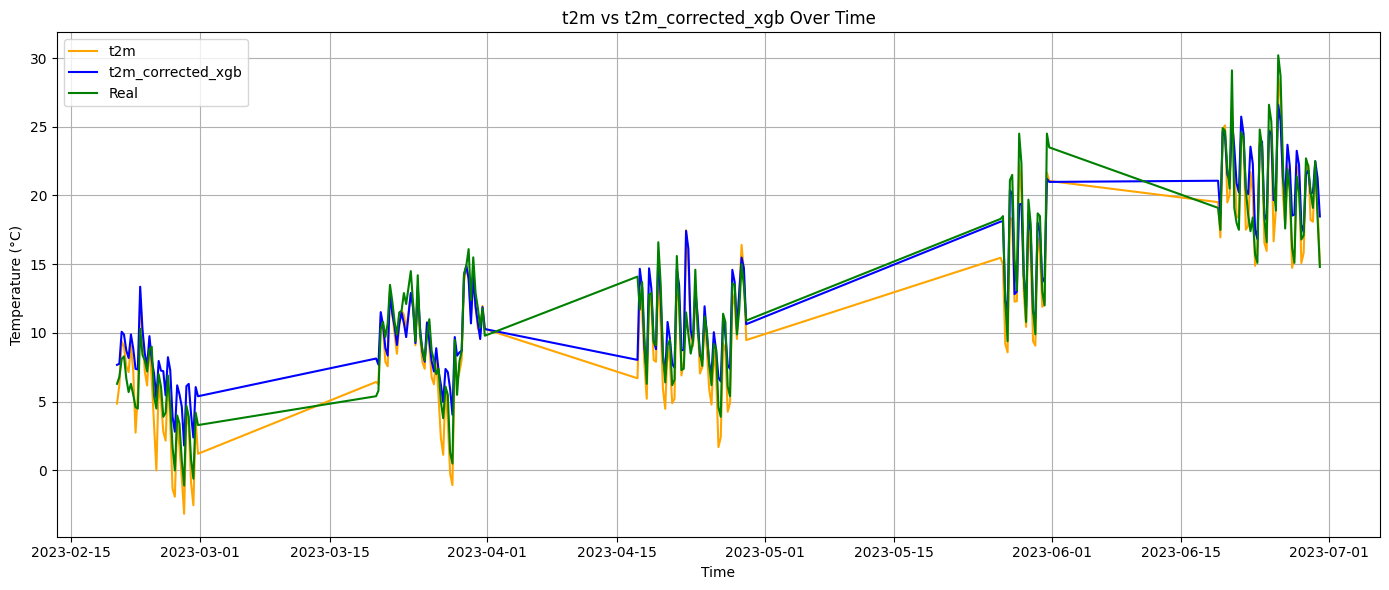

In [178]:
df_xgb = simple_data(val_df_X_copy, y_pred_val, y_val_real)
plot_temperatures(df_xgb, 'time', 't2m_mean', 't2m_corrected_mean', 't2m_real_first', label1='t2m', label2='t2m_corrected_xgb')

We’re doing pretty well — our predictions almost follow the same fluctuations as the actual temperatures. However, they tend to underestimate the temperature from March to July and overestimate it in February.


## 3-3 MLPRegressor :

MLPRegressor is a machine learning model from scikit-learn that implements a multi-layer perceptron (MLP) for regression tasks. An MLP is a type of feedforward artificial neural network composed of one or more hidden layers between the input and output layers. 

In this section, we tune the hyperparameters of our MLPRegressor using a randomized search with 3-fold cross-validation. To avoid overfitting, we enable early stopping, which halts training when the validation score does not improve further.


In [179]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import RandomizedSearchCV




# Add regularization to MLPRegressor by increasing 'alpha' (L2 penalty)
param_grid = {
    'hidden_layer_sizes': [(26,), (26,26), (42, 32), (128, 64)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam'],
    'alpha': [0.01, 0.1, 1.0],  # Stronger regularization values
    'learning_rate_init': [0.001, 0.01],
    'max_iter': [200]
}

mlp = MLPRegressor(early_stopping=True, random_state=42)
random_search_mlp = RandomizedSearchCV(
    mlp,
    param_distributions=param_grid,
    n_iter=20,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1,
    random_state=42
)
random_search_mlp.fit(X_train, y_train)

best_mlp_reg= random_search_mlp.best_estimator_

# Predict and inverse transform
y_pred_train_scaled = best_mlp_reg.predict(X_train)
y_pred_val_scaled = best_mlp_reg.predict(X_val)
y_pred_train = scaler_y.inverse_transform(y_pred_train_scaled.reshape(-1, 1))
y_pred_val_mlp = scaler_y.inverse_transform(y_pred_val_scaled.reshape(-1, 1))
y_train_real = scaler_y.inverse_transform(y_train.reshape(-1, 1))
y_val_real = scaler_y.inverse_transform(y_val.reshape(-1, 1))

# Metrics
def smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

mae_train = mean_absolute_error(y_train_real, y_pred_train)
mae_val = mean_absolute_error(y_val_real, y_pred_val_mlp)
smape_train = smape(y_train_real, y_pred_train)
smape_val = smape(y_val_real, y_pred_val_mlp)





Fitting 3 folds for each of 20 candidates, totalling 60 fits


In [180]:
# Show results in a table
results_df_mlp_reg = pd.DataFrame({
    "Metric": ["MAE", "sMAPE"],
    "Value_validation": [mae_val, smape_val],
    "Value_train": [mae_train, smape_train]
})
print(results_df_mlp_reg)

  Metric  Value_validation  Value_train
0    MAE          2.272135     1.359767
1  sMAPE         26.460833    19.727632


### Interpretation:

The MLPRegressor model achieves a mean absolute error (MAE) of about **2.80°C** on the validation set and **1.36°C** on the training set. This means that, on average, the model’s predictions are within 2.8°C of the actual temperature for unseen data, but much closer (1.4°C) for the training data. The symmetric mean absolute percentage error (sMAPE) is **30.5%** for validation and **19.5%** for training, indicating a higher relative error on the validation set.


In [181]:
# Number of hidden layers
print("Number of hidden layers:", len(best_mlp_reg.hidden_layer_sizes))

# Total number of layers (input + hidden + output)
print("Total number of layers:", len(best_mlp_reg.coefs_) + 1)

# Shape of each layer's weights
for i, w in enumerate(best_mlp_reg.coefs_):
    print(f"Layer {i} weights shape: {w.shape}")

Number of hidden layers: 1
Total number of layers: 3
Layer 0 weights shape: (26, 26)
Layer 1 weights shape: (26, 1)


In [182]:
# Get the absolute sum of weights for each input feature (first layer)
input_weights = np.abs(best_mlp_reg.coefs_[0])  # shape: (n_features, n_hidden_neurons)
feature_importance = input_weights.sum(axis=1)  # sum over hidden neurons

# Normalize and create a DataFrame for easier viewing
feature_importance = feature_importance / feature_importance.sum()
importance_df = pd.DataFrame({
    'feature': train_df_X.columns,
    'importance': feature_importance
}).sort_values(by='importance', ascending=False)

print(importance_df)

      feature    importance
11        t2m  8.449991e-02
22        day  8.443807e-02
23       hour  7.810483e-02
0      number  7.709636e-02
25       week  7.443428e-02
17        skt  7.260546e-02
6        sshf  5.160783e-02
14        str  5.105315e-02
19         st  4.141501e-02
9         u10  3.806793e-02
18         sm  3.599042e-02
10        v10  3.047055e-02
4          sp  2.975769e-02
7        slhf  2.811610e-02
8         msl  2.779775e-02
24      month  2.713257e-02
21         tp  2.472818e-02
15        ttr  2.438251e-02
16       sund  2.293518e-02
20        tcc  2.194843e-02
12        d2m  2.157443e-02
3        cape  1.864277e-02
13        ssr  1.799763e-02
5         tcw  1.516370e-02
1    latitude  3.925122e-05
2   longitude  1.226764e-34


The important features identified by the MLPRegressor are notably, they align well with human intuition—such as t2m, month, hour, and day—which makes them feel accurate. The only exception is the number feature, which is difficult to interpret. We know it doesn’t help with prediction, as it's just a categorical column used to enumerate the forecasts. 

**It's also worth noting that these features—except t2m—were not scaled like the others, which likely influenced the model's weights, especially since MLPs are sensitive to feature scales.**

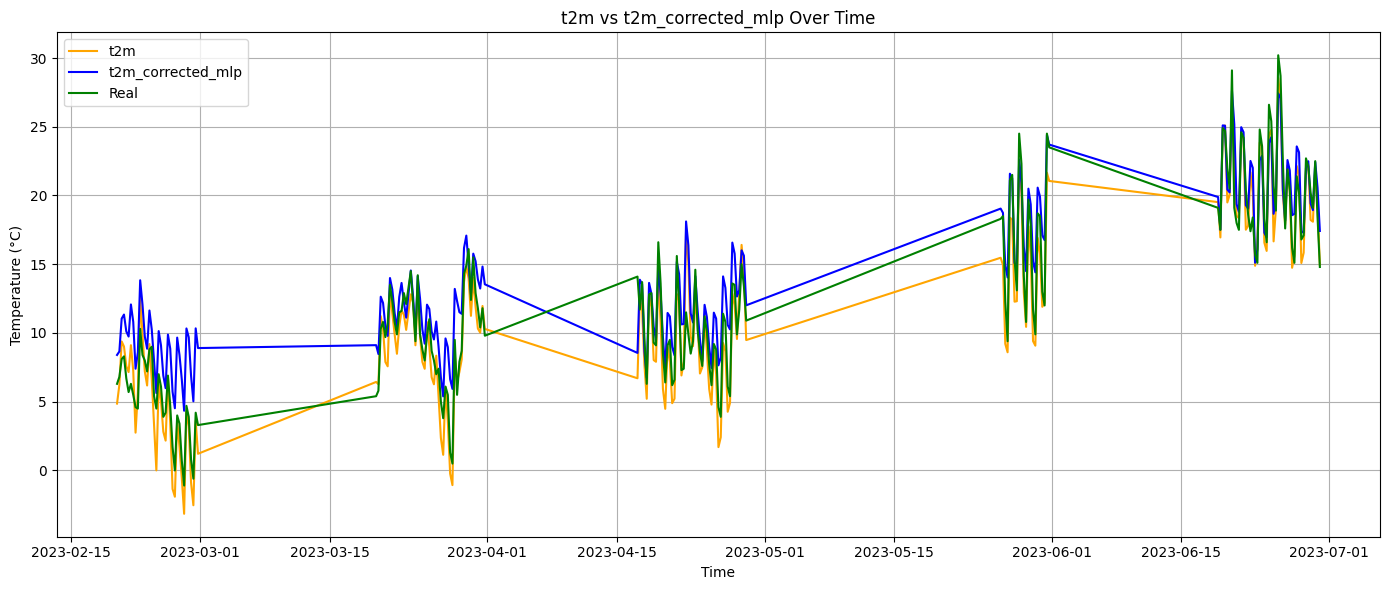

In [183]:
df_xgb = simple_data(val_df_X_copy, y_pred_val_mlp, y_val_real)
plot_temperatures(df_xgb, 'time', 't2m_mean', 't2m_corrected_mean', 't2m_real_first', label1='t2m', label2='t2m_corrected_mlp')

We’re doing fairly well — our predictions almost follow the same fluctuations as the actual temperatures. However, they tend to underestimate the temperature from mai to June and overestimate it in February-april.



# 4 Testing the models :

for this, we will use the forecasts of 2024, between February and June:  
a 100% unseen dataset.



## 4-1- Preparing data :

 We will upload the files the same way we did for the training files.

In [184]:
test_data = merge_forecast_files("forecast_2024_02_01_till_2024_06_30_ECMWF")

In [185]:
vlinder_2024 =  pd.read_csv('Vlinder 2023/vlinder19_2024_clean.csv')
vlinder_2024.rename(columns={"datetime":"time"}, inplace=True)
vlinder_2024["time"]=pd.to_datetime(vlinder_2024["time"])
vlinder_2024= preprocess_target_df(vlinder_2024, start_date="2024-02-01", end_date="2024-07-07")


C:\Users\CYTech Student\AppData\Local\Temp\ipykernel_7836\1769505683.py:16: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  target_df = target_df.resample("60T").first()


here we try to merge the 50 forecasts for every time stamp with the vlinder data.
the purpose is to calculate the error for the 50 forecasts later.
and delete the raws that contant temperature in vlinder 

In [186]:
def merge_predictions_with_vlinder(X_test, target_df, target_col='Temperatuur', time_col='time'):
    """
    merge the 50 forecasts for every time stamp with the vlinder data.
    the purpose is to calculate the error for the 50 forecasts later.

    Parameters:
        test_data (pd.DataFrame): The test dataset containing the time column.
        predictions (np.ndarray): The predicted values (same order as test_data).
        target_df (pd.DataFrame): The dataframe containing the true target values and time column.
        target_col (str): Name of the column with true target values in target_df.
        time_col (str): Name of the time column to merge on.

    Returns:
        pd.DataFrame: Merged dataframe with columns [time_col, target_col, 'pred_temp'] and no missing values.
    """
    X_test = X_test.copy().reset_index(drop=True)

    merged = pd.merge(X_test, target_df, on="time", how='left')
    mergerd = merged.dropna(subset=[target_col])
    merged.rename(columns={target_col: 'temp'}, inplace=True)
    temp_to_delete = find_constant_temp(merged)
    print(temp_to_delete)  # delete the constant temperatures in the vlinder data
    merged = merged.drop(index=temp_to_delete)
    merged = merged.drop(merged[merged["time"].isin(temp_to_delete)].index)

    
    test_data = merged.drop(columns=["temp"])
    y_test= merged["temp"]
    return y_test, test_data

In [187]:
y_test, test_data = merge_predictions_with_vlinder(test_data, vlinder_2024, target_col='Temperatuur', time_col='time')

[]



Now that we have our test data frames ready, we need to process them in the same way as we did for the training set. This includes handling missing values and normalizing the data using the same scaler as for the training set. We will group all these steps into the following function.



In [188]:
def processing_test_data(data):
    # Identify columns with missing values
    LMV, MV = missing_values(data)
    columns_to_delete = LMV + MV
    data = data.drop(columns=columns_to_delete, errors='ignore')
    

    
    
    # Feature engineering
    data = convert_time_to_int(data)
    if "time" in data.columns:
        data = data.drop(columns=["time"])
    
    # Ensure columns order matches training features
    data = data[[col for col in train_df_X.columns if col in data.columns]]
    
    # Normalize using the scaler fitted on training data
    numeric_columns_X = [col for col in data.select_dtypes(include=['float64', 'int64']).columns if col != 'number']
    data[numeric_columns_X] = scaler_X.transform(data[numeric_columns_X])
    
    return data

In [189]:
test_data_scaled = processing_test_data(test_data)


 ## 4-2 Evaluating the models :



Now, let's evaluate our models on the test data.  
The following function removes NaN values from `y_test` and aligns `y_test_pred` accordingly, then computes the MAE and sMAPE metrics.



In [190]:
def evaluate_test_predictions(y_test, y_test_pred):
    """
    Remove NaNs from y_test and align y_test_pred accordingly, then compute MAE and sMAPE.

    Parameters:
        y_test (pd.Series): True target values (may contain NaNs).
        y_test_pred (np.ndarray): Predicted values (same order as y_test).

    Returns:
        tuple: (mae, smape, y_test_no_nan, y_test_pred_no_nan)
    """
    # Remove NaNs from y_test and align y_test_pred accordingly
    mask = ~y_test.isna()
    y_test_no_nan = y_test[mask]
    y_test_pred_no_nan = y_test_pred[mask.values] if hasattr(y_test_pred, '__getitem__') else y_test_pred

    mae = mean_absolute_error(y_test_no_nan, y_test_pred_no_nan.ravel())
    smape_val = smape(y_test_no_nan.values, y_test_pred_no_nan.ravel())
    return mae, smape_val, y_test_no_nan, y_test_pred_no_nan

### 1- linear regression : 

In [191]:


# Select only the columns used by the model (selected features)
selected_feature_names = train_df_X.columns[selector.support_]
test_data_scaled_selected = test_data_scaled[selected_feature_names]

# Predict using the model
y_test_linear_scaled = model_selected.predict(test_data_scaled_selected)
y_test_pred = scaler_y.inverse_transform(y_test_linear_scaled.reshape(-1, 1))

# Evaluate predictions
mae_linear,smape_linear = evaluate_test_predictions(y_test, y_test_pred)[0], evaluate_test_predictions(y_test, y_test_pred)[1]


c:\Users\CYTech Student\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


### 2- XGBoost :

In [192]:
# Ensure test data columns match those used for training
test_data_xgb = test_data_scaled[train_df_X.columns]

y_test_xgb_scaled = best_xgb.predict(test_data_xgb)
y_test_xgb_pred = scaler_y.inverse_transform(y_test_xgb_scaled.reshape(-1, 1))

# Evaluate predictions
mae_xgb, smape_xgb, y_test_no_nan, y_test_pred_no_nan = evaluate_test_predictions(y_test, y_test_xgb_pred)

### 3-MLPRegressor 

In [193]:
y_test_mlp_scaled = best_mlp_reg.predict(test_data_xgb)
y_test_mlp_pred = scaler_y.inverse_transform(y_test_mlp_scaled.reshape(-1, 1))

# Evaluate predictions
mae_mlp, smape_mlp, y_test_no_nan, y_test_pred_no_nan = evaluate_test_predictions(y_test, y_test_mlp_pred)

c:\Users\CYTech Student\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but MLPRegressor was fitted without feature names
  warnings.warn(


## 4-3 Results:

In [194]:
# results table 
results_df_test = pd.DataFrame({
    "Metric": ["MAE", "sMAPE"],
    "linear regression": [mae_linear, smape_linear],
    "XGBoost ": [mae_xgb, smape_xgb],
    "MLPRegressor": [mae_mlp, smape_mlp]
})
print(results_df_test)

  Metric  linear regression   XGBoost   MLPRegressor
0    MAE           3.962009   1.614122      2.021343
1  sMAPE          31.068713  14.197825     18.011035





### 4-3-1. **Performance Analysis**

- **Linear Regression**:  
  - MAE and sMAPE are generally reasonable, but they are higher than those of the other models.  
  - The model tends to underfit compared to more complex models.

- **XGBoost**:  
  - Achieves the lowest MAE and sMAPE, indicating it best captures nonlinear relationships and interactions between variables.
  - Generalizes well.

- **MLPRegressor**:  
  - Performance on the test set is similar to the validation set, but generally not as strong as XGBoost.




### 4-3-2. Visualisations

The code above did not manage to remove the rows where the Vlinder temperature is wrong (i.e., constant values). However, we can still continue with our analysis. This error will not overestimate the performance of our model, but rather underestimate it. So, we should keep in mind that our model likely performs better and has fewer errors than what we observe here.

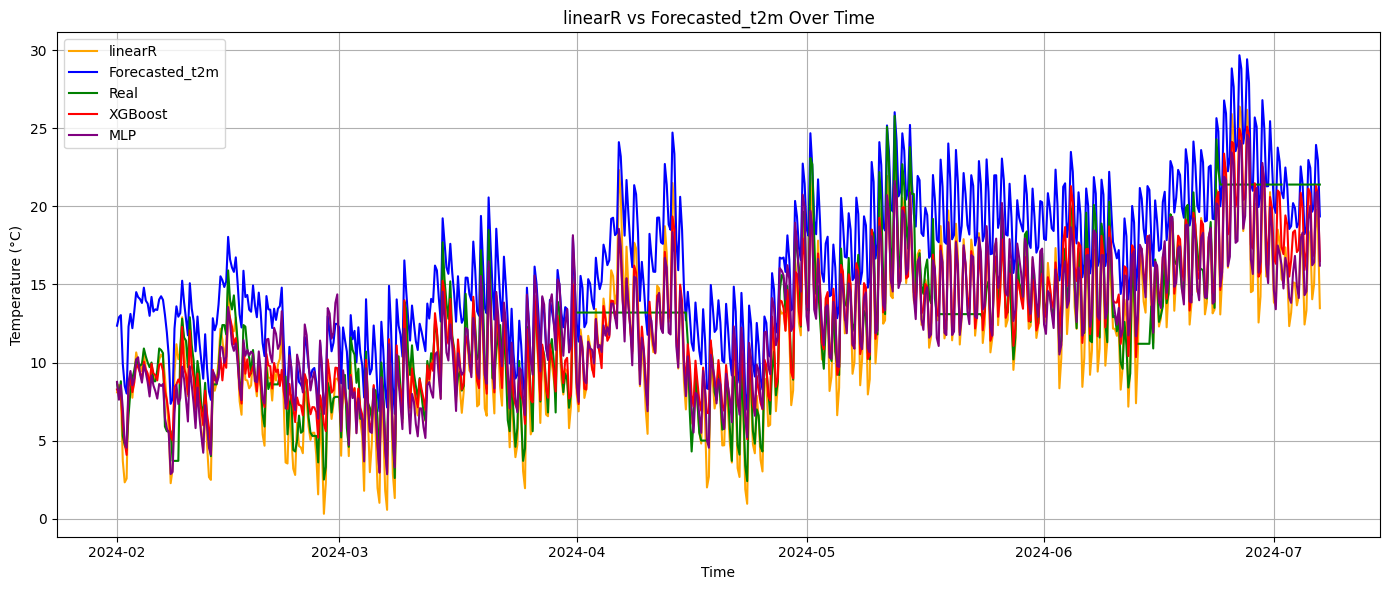

In [195]:
# Use the existing 'time' column if present to avoid invalid date errors
df_plot = test_data.copy()

# Add predictions to the DataFrame for plotting
df_plot['t2m_corrected'] = y_test_pred.flatten()
df_plot['t2m_real'] = y_test.values
df_plot['y_test_xgb_pred'] = y_test_xgb_pred.flatten()
df_plot['y_test_mlp_pred'] = y_test_mlp_pred.flatten()

# Group by time and compute means for plotting 
plot_df = df_plot.groupby('time', as_index=False)[
    ['t2m', 't2m_corrected', 't2m_real', 'y_test_xgb_pred', 'y_test_mlp_pred']
].mean()
plot_df['t2m_mean'] = plot_df['t2m'] - 273.15  # Convert from Kelvin to Celsius 

plot_temperatures(
    plot_df, 'time', 't2m_mean', 't2m_corrected', 't2m_real',
    label1='linearR', label2='Forecasted_t2m',
    col4='y_test_xgb_pred', label4='XGBoost',
    col5='y_test_mlp_pred', label5='MLP'
)

Wow! We definitely can't see anything on this plot.
Let's zoom in on specific periods to better analyze the results and compare the models.

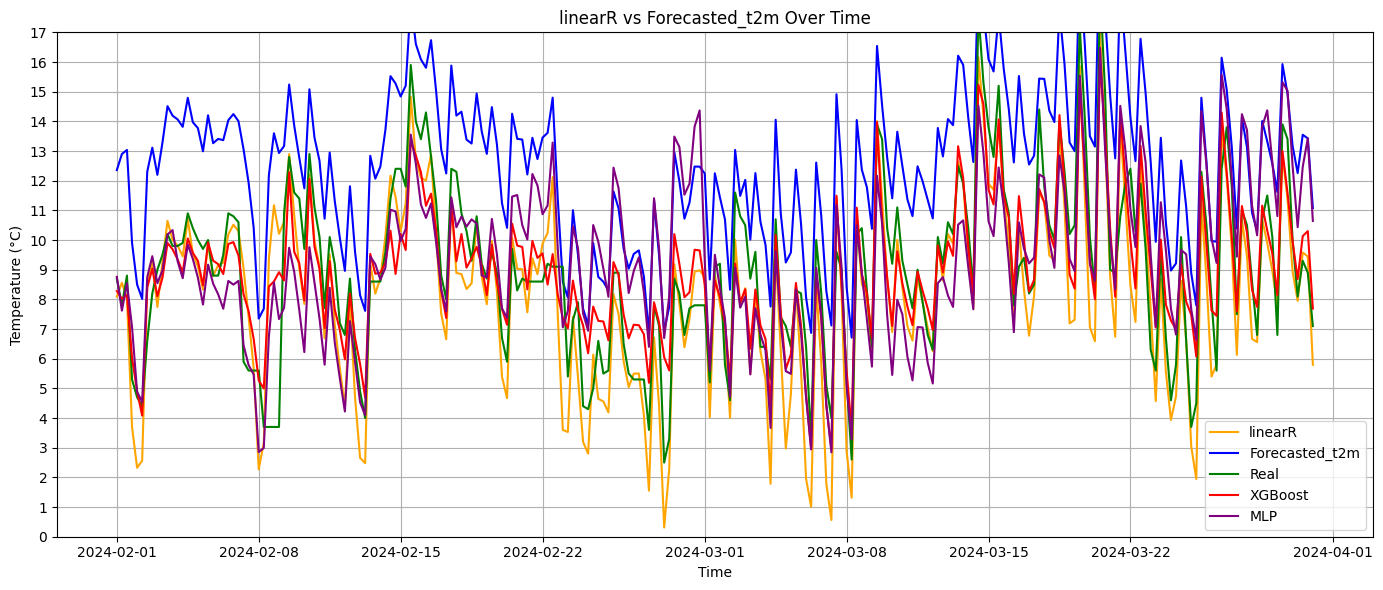

In [196]:
# Filter for the  period (February and March 2024)
mask = (plot_df['time'] >= '2024-02-01') & (plot_df['time'] <= '2024-03-31')
plot_df_zoom = plot_df.loc[mask]

plot_temperatures(
    plot_df_zoom, 'time', 't2m_mean', 't2m_corrected', 't2m_real',
    label1='linearR', label2='Forecasted_t2m',
    col4='y_test_xgb_pred', label4='XGBoost',
    col5='y_test_mlp_pred', label5='MLP',
    ylim=(0, 17),      # Zoom on 0 to 10°C
    yticks_step=1      # Tick every 1°C
)

We can see that in February and March, our models perform better than t2m: all the colors are close to the green line, except for the blue, which overestimates the temperature. Overall, we are doing well—both the linear model and XGBoost are closer to the real values than MLP.

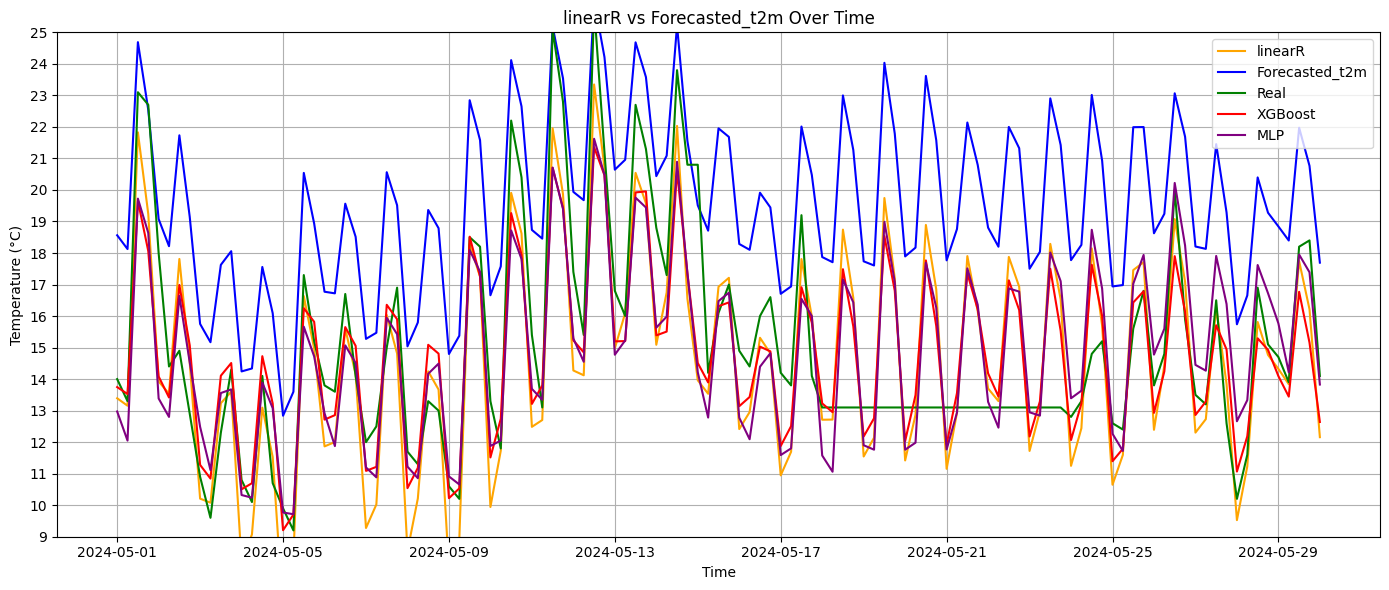

In [197]:
# Filter for the desired period (May 2024)
mask = (plot_df['time'] >= pd.to_datetime('2024-05-01')) & (plot_df['time'] <= pd.to_datetime('2024-05-30'))
plot_df_zoom = plot_df.loc[mask]

plot_temperatures(
    plot_df_zoom, 'time', 't2m_mean', 't2m_corrected', 't2m_real',
    label1='linearR', label2='Forecasted_t2m',
    col4='y_test_xgb_pred', label4='XGBoost',
    col5='y_test_mlp_pred', label5='MLP',
    ylim=(9, 25),      # Zoom on 9 to 25°C
    yticks_step=1      # Tick marks every 1°C
)

If we look only at the month of May:  
Linear regression is really far off on some days, underestimating the results. XGBoost is close, but overall, it also underestimates the temperature. MLP is in between, and generally closer than linear regression, but not like xgboost.

Bref, XGBoost is the best.

_____________________________________________


The end
Thank you for reading